# 3.2 Two-Dimensional (2D) Random Walk

#### Definition
The walker moves on a flat 2D plane (grid). At each step, it moves in one of four cardinal directions:

$$\text{Direction} \in \{\ \text{Up},\ \text{Down},\ \text{Left},\ \text{Right}\ \}, \quad \text{each with prob.} = \frac{1}{4}$$

#### Position Update Rule

$$x_n = x_{n-1} + \Delta x, \quad y_n = y_{n-1} + \Delta y$$

where $(\Delta x, \Delta y)$ is one of: $(+1,0),\ (-1,0),\ (0,+1),\ (0,-1)$

#### Distance from Origin

$$r_n = \sqrt{x_n^2 + y_n^2}$$

#### Properties
| Property | Value |
|---|---|
| Directions | 4 (Up, Down, Left, Right) |
| Plane | X-Y |
| RMS distance | $\sqrt{N}$ |
| Returns to origin? | Yes (probability = 1 as $N \to \infty$) |

> **Pólya's Theorem:** In 2D, a random walk will return to the origin with probability **1** (certain).

---

In [19]:
import numpy as np
import matplotlib.pyplot as plt


In [20]:
rng = np.random.default_rng(seed=123045)
def random_walk_2D(no_of_steps: int):
    x, y = 0, 0
    walk_x, walk_y = [x], [y]

    for _ in range(no_of_steps):
        direction = np.random.choice(['R', 'L', 'U', 'D'])
        if direction == 'R':   x += 1
        elif direction == 'L': x -= 1
        elif direction == 'U': y += 1
        elif direction == 'D': y -= 1

        walk_x.append(x)
        walk_y.append(y)

    return (x, y), walk_x, walk_y

print(random_walk_2D(100)[0])


(6, 4)


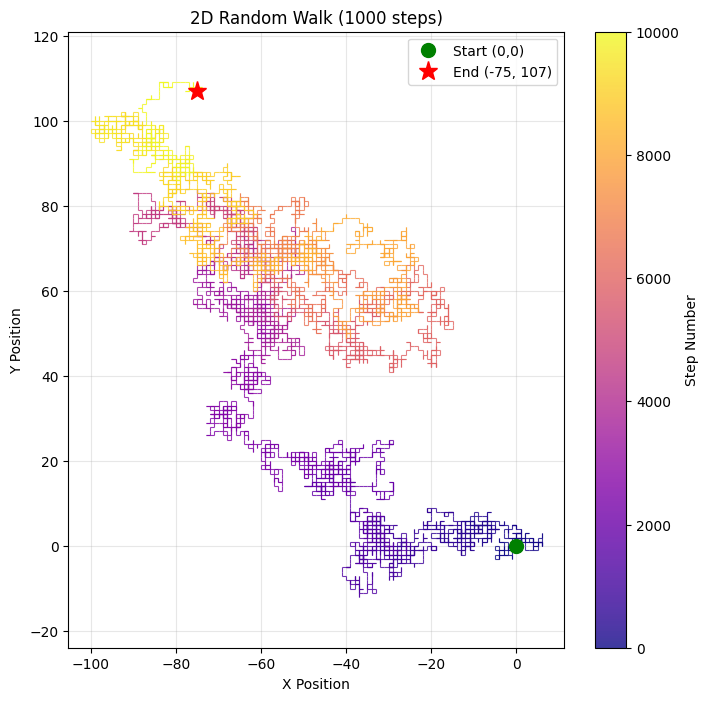

In [21]:
(final_pos), walk_x, walk_y = random_walk_2D(10000)

plt.figure(figsize=(8, 8))

# Gradient color to show progression of walk
points = np.array([walk_x, walk_y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

from matplotlib.collections import LineCollection
norm_color = plt.Normalize(0, len(walk_x))
lc = LineCollection(segments, cmap='plasma', norm=norm_color, linewidth=0.8, alpha=0.8)
lc.set_array(np.arange(len(walk_x)))
plt.gca().add_collection(lc)

# Start and end markers
plt.plot(walk_x[0],  walk_y[0],  'go', markersize=10, label='Start (0,0)',        zorder=5)
plt.plot(walk_x[-1], walk_y[-1], 'r*', markersize=14, label=f'End {final_pos}',   zorder=5)

plt.colorbar(lc, label='Step Number')
plt.autoscale()
plt.title('2D Random Walk (1000 steps)')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

In [22]:
# total distanc traveled 
distance = np.sqrt(np.array(walk_x) **2 + np.array(walk_y) **2)
print(distance)
steps_nums = len(distance)
print(f"Final Distance from Origin: {distance[-1]:.2f}")
print(f"Theoretical Expected (√N):  {np.sqrt(1000):.2f}")

[  0.           1.           2.         ... 130.91982279 131.487642
 130.667517  ]
Final Distance from Origin: 130.67
Theoretical Expected (√N):  31.62


* as N goes to infinity the random walk will atleast once return to its origin